# Notebook 8 — Tests Statistiques

Objectif : valider statistiquement les relations observées entre les variables, en contrôlant le risque d'erreur.

**Outil principal :** SciPy (`scipy.stats`)

---
### Logique des tests statistiques
Chaque test répond à une question précise avec une **p-value** :
- p < 0.05 → on rejette H₀ (résultat statistiquement significatif)
- p ≥ 0.05 → on ne peut pas rejeter H₀

On présente : la question posée, le test adapté, les hypothèses, et l'interprétation.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import (
    pearsonr, spearmanr, kendalltau,
    ttest_ind, mannwhitneyu,
    f_oneway, kruskal,
    chi2_contingency, shapiro, levene
)
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('dataset_engineered.csv')
print(f'Dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')

# Fonction utilitaire pour afficher les résultats proprement
def print_test(test_name, statistic, pvalue, alpha=0.05):
    sig = ' Significatif' if pvalue < alpha else ' Non significatif'
    print(f'{test_name}')
    print(f'  Statistique  : {statistic:.4f}')
    print(f'  p-value      : {pvalue:.6f}')
    print(f'  Conclusion   : {sig} (α = {alpha})')
    print()

Dataset : 15,000 lignes × 45 colonnes


## 1. Tests préliminaires : normalité et homogénéité des variances

Avant de choisir un test, on vérifie si les données suivent une **loi normale** (condition de nombreux tests paramétriques).

In [17]:
# Test de Shapiro-Wilk (sur échantillon car limité à ~5000 obs)
key_vars = ['daily_screen_time_hours', 'sleep_duration_hours', 'stress_level', 'mental_fatigue_score']
sample = df.sample(n=3000, random_state=42)

print('=== Test de normalité de Shapiro-Wilk ===')
print('H₀ : la variable suit une loi normale\n')
print(f'{"Variable":<40} {"Statistique W":>15} {"p-value":>12} {"Normale ?"}')
print('-' * 80)
for col in key_vars:
    w, p = shapiro(sample[col].dropna())
    normale = ' Oui (p>0.05)' if p > 0.05 else ' Non (p<0.05)'
    print(f'{col:<40} {w:>15.4f} {p:>12.6f} {normale}')

print('\n→ Si les données ne sont pas normales, on utilisera des tests non paramétriques.')

=== Test de normalité de Shapiro-Wilk ===
H₀ : la variable suit une loi normale

Variable                                   Statistique W      p-value Normale ?
--------------------------------------------------------------------------------
daily_screen_time_hours                           0.9511     0.000000  Non (p<0.05)
sleep_duration_hours                              0.9537     0.000000  Non (p<0.05)
stress_level                                      0.8978     0.000000  Non (p<0.05)
mental_fatigue_score                              0.9080     0.000000  Non (p<0.05)

→ Si les données ne sont pas normales, on utilisera des tests non paramétriques.


In [18]:
# Test de Levene : homogénéité des variances entre groupes (Male vs Female)
male   = df.loc[df['gender'] == 'Male',   'daily_screen_time_hours'].dropna()
female = df.loc[df['gender'] == 'Female', 'daily_screen_time_hours'].dropna()

lev_stat, lev_p = levene(male, female)
print('=== Test de Levene — Homogénéité des variances ===')
print('H₀ : les variances de Male et Female sont égales\n')
print_test('Levene (screen_time : Male vs Female)', lev_stat, lev_p)
print(f'  Variance Male   : {male.var():.4f}')
print(f'  Variance Female : {female.var():.4f}')

=== Test de Levene — Homogénéité des variances ===
H₀ : les variances de Male et Female sont égales

Levene (screen_time : Male vs Female)
  Statistique  : 0.0018
  p-value      : 0.966457
  Conclusion   :  Non significatif (α = 0.05)

  Variance Male   : 6.7184
  Variance Female : 6.7793


## 2. Tests de corrélation

### Question : le temps d'écran est-il significativement lié au sommeil et au stress ?

In [19]:
df_clean = df.dropna(subset=['daily_screen_time_hours', 'sleep_duration_hours', 'stress_level'])

print('=== Tests de corrélation : daily_screen_time_hours ===\n')

for target in ['sleep_duration_hours', 'stress_level']:
    x = df_clean['daily_screen_time_hours']
    y = df_clean[target]
    
    # Pearson (linéaire, suppose normalité)
    r_p, p_p   = pearsonr(x, y)
    # Spearman (monotone, non paramétrique)
    r_s, p_s   = spearmanr(x, y)
    # Kendall (concordance, robuste aux outliers)
    r_k, p_k   = kendalltau(x.sample(3000, random_state=42), y.sample(3000, random_state=42))
    
    print(f'--- Temps d\'écran → {target} ---')
    print(f'  Pearson  : r = {r_p:+.4f}  p = {p_p:.2e}')
    print(f'  Spearman : ρ = {r_s:+.4f}  p = {p_s:.2e}')
    print(f'  Kendall  : τ = {r_k:+.4f}  p = {p_k:.2e}')
    print()

=== Tests de corrélation : daily_screen_time_hours ===

--- Temps d'écran → sleep_duration_hours ---
  Pearson  : r = -0.0019  p = 8.19e-01
  Spearman : ρ = -0.0019  p = 8.19e-01
  Kendall  : τ = +0.0014  p = 9.08e-01

--- Temps d'écran → stress_level ---
  Pearson  : r = +0.8790  p = 0.00e+00
  Spearman : ρ = +0.8938  p = 0.00e+00
  Kendall  : τ = +0.7156  p = 0.00e+00



In [20]:
# Visualisation des corrélations avec intervalles de confiance (bootstrap)
from scipy.stats import bootstrap

variables_test = [
    ('daily_screen_time_hours', 'sleep_duration_hours'),
    ('daily_screen_time_hours', 'stress_level'),
    ('phone_usage_before_sleep_minutes', 'sleep_quality_score'),
    ('physical_activity_minutes', 'stress_level'),
    ('mental_fatigue_score', 'stress_level'),
]

results_corr = []
for x_col, y_col in variables_test:
    data = df[[x_col, y_col]].dropna()
    r, p = spearmanr(data[x_col], data[y_col])
    # Bootstrap 95% CI sur r de Spearman
    def spearman_stat(x, y):
        return spearmanr(x, y).statistic
    boot = bootstrap((data[x_col].values, data[y_col].values), spearman_stat,
                     n_resamples=500, random_state=42, paired=True)
    results_corr.append({
        'Relation'    : f'{x_col} → {y_col}',
        'ρ Spearman'  : round(r, 4),
        'p-value'     : p,
        'IC95 bas'    : round(boot.confidence_interval.low, 4),
        'IC95 haut'   : round(boot.confidence_interval.high, 4),
        'Significatif': 'Oui' if p < 0.05 else 'Non',
    })

corr_df = pd.DataFrame(results_corr)
print(corr_df.to_string(index=False))

                                              Relation  ρ Spearman  p-value  IC95 bas  IC95 haut Significatif
        daily_screen_time_hours → sleep_duration_hours     -0.0019 0.819197   -0.0161     0.0135          Non
                daily_screen_time_hours → stress_level      0.8938 0.000000    0.8910     0.8965          Oui
phone_usage_before_sleep_minutes → sleep_quality_score     -0.3237 0.000000   -0.3367    -0.3068          Oui
              physical_activity_minutes → stress_level      0.0082 0.315512   -0.0096     0.0230          Non
                   mental_fatigue_score → stress_level      0.9307 0.000000    0.9284     0.9331          Oui


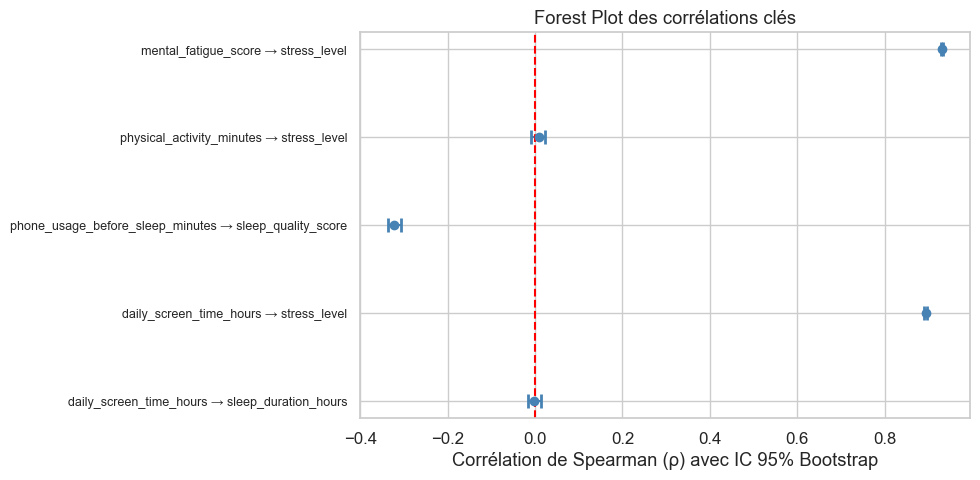

In [21]:
# Forest plot des corrélations avec IC 95%
fig, ax = plt.subplots(figsize=(10, 5))

y_pos = range(len(corr_df))
ax.errorbar(
    corr_df['ρ Spearman'], y_pos,
    xerr=[corr_df['ρ Spearman'] - corr_df['IC95 bas'],
          corr_df['IC95 haut'] - corr_df['ρ Spearman']],
    fmt='o', color='steelblue', capsize=5, capthick=2, elinewidth=1.5
)
ax.axvline(0, color='red', linestyle='--', lw=1.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(corr_df['Relation'], fontsize=9)
ax.set_xlabel('Corrélation de Spearman (ρ) avec IC 95% Bootstrap')
ax.set_title('Forest Plot des corrélations clés')
plt.tight_layout()
plt.show()

## 3. Comparaison de groupes — t-test et Mann-Whitney

### Question : les grands utilisateurs de smartphones dorment-ils moins que les autres ?

In [22]:
# Groupes : utilisateurs intensifs (>6h/j) vs modérés (<=6h/j)
heavy = df.loc[df['daily_screen_time_hours'] > 6, 'sleep_duration_hours'].dropna()
light = df.loc[df['daily_screen_time_hours'] <= 6, 'sleep_duration_hours'].dropna()

print(f'Groupe intensif (>6h/j) : n={len(heavy):,}  moyenne={heavy.mean():.3f}h  std={heavy.std():.3f}')
print(f'Groupe modéré  (≤6h/j) : n={len(light):,}  moyenne={light.mean():.3f}h  std={light.std():.3f}')
print()

# t-test de Welch (ne suppose pas l'égalité des variances)
t_stat, t_p = ttest_ind(heavy, light, equal_var=False)
print_test('t-test de Welch (sleep_duration : heavy vs light user)', t_stat, t_p)

# Mann-Whitney U (non paramétrique — à préférer si non normal)
u_stat, u_p = mannwhitneyu(heavy, light, alternative='two-sided')
print_test('Mann-Whitney U (sleep_duration : heavy vs light user)', u_stat, u_p)

# Taille de l'effet (Cohen's d)
cohens_d = (heavy.mean() - light.mean()) / np.sqrt((heavy.std()**2 + light.std()**2) / 2)
print(f'Taille de l\'effet (Cohen\'s d) : {cohens_d:.4f}')
print('Interprétation : |d| < 0.2 = négligeable | 0.2-0.5 = petit | 0.5-0.8 = moyen | > 0.8 = grand')

Groupe intensif (>6h/j) : n=6,615  moyenne=6.512h  std=1.454
Groupe modéré  (≤6h/j) : n=8,385  moyenne=6.508h  std=1.450

t-test de Welch (sleep_duration : heavy vs light user)
  Statistique  : 0.1603
  p-value      : 0.872658
  Conclusion   :  Non significatif (α = 0.05)

Mann-Whitney U (sleep_duration : heavy vs light user)
  Statistique  : 27774323.0000
  p-value      : 0.876461
  Conclusion   :  Non significatif (α = 0.05)

Taille de l'effet (Cohen's d) : 0.0026
Interprétation : |d| < 0.2 = négligeable | 0.2-0.5 = petit | 0.5-0.8 = moyen | > 0.8 = grand


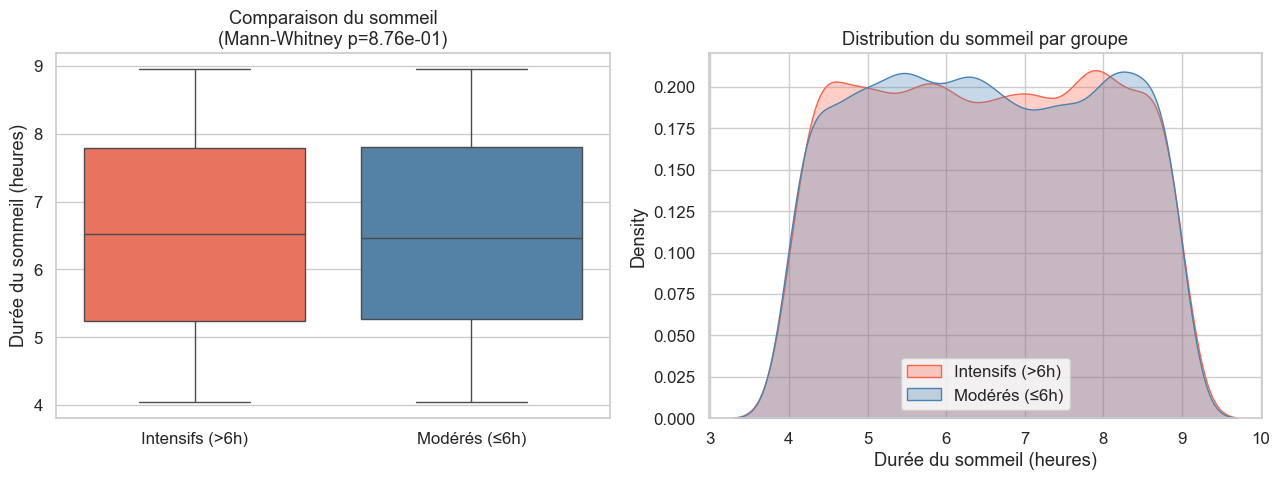

In [23]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
sns.boxplot(data=[heavy.values, light.values], ax=axes[0], palette=['tomato', 'steelblue'])
axes[0].set_xticklabels(['Intensifs (>6h)', 'Modérés (≤6h)'])
axes[0].set_ylabel('Durée du sommeil (heures)')
axes[0].set_title(f'Comparaison du sommeil\n(Mann-Whitney p={u_p:.2e})')

# Distribution
for data, label, color in [(heavy, 'Intensifs (>6h)', 'tomato'), (light, 'Modérés (≤6h)', 'steelblue')]:
    sns.kdeplot(data, ax=axes[1], label=label, color=color, fill=True, alpha=0.3)
axes[1].set_xlabel('Durée du sommeil (heures)')
axes[1].set_title('Distribution du sommeil par groupe')
axes[1].legend()

plt.tight_layout()
plt.show()

In [24]:
# Test similaire pour le stress
heavy_stress = df.loc[df['daily_screen_time_hours'] > 6, 'stress_level'].dropna()
light_stress  = df.loc[df['daily_screen_time_hours'] <= 6, 'stress_level'].dropna()

print(f'Stress — Intensifs : {heavy_stress.mean():.3f}  |  Modérés : {light_stress.mean():.3f}')
u2, p2 = mannwhitneyu(heavy_stress, light_stress, alternative='two-sided')
print_test('Mann-Whitney U (stress_level : heavy vs light user)', u2, p2)

cohens_d2 = (heavy_stress.mean() - light_stress.mean()) / np.sqrt((heavy_stress.std()**2 + light_stress.std()**2) / 2)
print(f'Cohen\'s d : {cohens_d2:.4f}')

Stress — Intensifs : 9.338  |  Modérés : 5.120
Mann-Whitney U (stress_level : heavy vs light user)
  Statistique  : 53034150.5000
  p-value      : 0.000000
  Conclusion   :  Significatif (α = 0.05)

Cohen's d : 2.4529


## 4. Comparaison de plusieurs groupes — ANOVA et Kruskal-Wallis

### Question : le niveau de stress varie-t-il selon la profession ?

In [25]:
# Groupes par profession
occupations = df['occupation'].dropna().unique()
groups = [df.loc[df['occupation'] == occ, 'stress_level'].dropna().values for occ in occupations]

print(f'Professions analysées : {list(occupations)}\n')
for occ, grp in zip(occupations, groups):
    print(f'  {occ:<20} n={len(grp):>5}  moyenne={np.mean(grp):.3f}  std={np.std(grp):.3f}')

print()
# ANOVA one-way (paramétrique)
f_stat, f_p = f_oneway(*groups)
print_test('ANOVA one-way (stress_level par profession)', f_stat, f_p)

# Kruskal-Wallis (non paramétrique — recommandé si non normal)
kw_stat, kw_p = kruskal(*groups)
print_test('Kruskal-Wallis (stress_level par profession)', kw_stat, kw_p)

Professions analysées : ['Designer', 'Teacher', 'Software Engineer', 'Manager', 'Student', 'Freelancer', 'Doctor', 'Researcher']

  Designer             n= 1813  moyenne=6.874  std=2.782
  Teacher              n= 1797  moyenne=6.898  std=2.798
  Software Engineer    n= 1917  moyenne=7.024  std=2.736
  Manager              n= 1962  moyenne=7.060  std=2.708
  Student              n= 1861  moyenne=7.185  std=2.677
  Freelancer           n= 1891  moyenne=6.899  std=2.742
  Doctor               n= 1922  moyenne=6.968  std=2.783
  Researcher           n= 1837  moyenne=6.923  std=2.758

ANOVA one-way (stress_level par profession)
  Statistique  : 2.7520
  p-value      : 0.007426
  Conclusion   :  Significatif (α = 0.05)

Kruskal-Wallis (stress_level par profession)
  Statistique  : 18.1471
  p-value      : 0.011324
  Conclusion   :  Significatif (α = 0.05)



In [26]:
# Si ANOVA significatif → post-hoc de Dunn (comparaisons deux à deux)
# Avec correction de Bonferroni pour le problème des comparaisons multiples
from itertools import combinations

pairs = list(combinations(range(len(occupations)), 2))
pvalues_pairs = []

for i, j in pairs:
    _, p = mannwhitneyu(groups[i], groups[j], alternative='two-sided')
    pvalues_pairs.append(p)

# Correction de Bonferroni-Holm
reject, pvals_corrected, _, _ = multipletests(pvalues_pairs, method='holm')

posthoc_df = pd.DataFrame([
    {
        'Groupe 1'    : occupations[i],
        'Groupe 2'    : occupations[j],
        'p brute'     : round(pvalues_pairs[k], 6),
        'p corrigée'  : round(pvals_corrected[k], 6),
        'Significatif': 'Oui' if reject[k] else 'Non',
    }
    for k, (i, j) in enumerate(pairs)
]).sort_values('p corrigée')

print('Post-hoc Mann-Whitney avec correction Holm (p<0.05 après correction) :')
print(posthoc_df.head(15).to_string(index=False))

Post-hoc Mann-Whitney avec correction Holm (p<0.05 après correction) :
Groupe 1          Groupe 2  p brute  p corrigée Significatif
Designer           Student 0.000661    0.018498          Oui
 Student        Freelancer 0.000999    0.026980          Oui
 Teacher           Student 0.003959    0.102933          Non
 Student        Researcher 0.004556    0.113903          Non
 Student            Doctor 0.019366    0.464776          Non
Designer        Freelancer 0.864048    1.000000          Non
Designer Software Engineer 0.102579    1.000000          Non
Designer           Teacher 0.632481    1.000000          Non
 Teacher Software Engineer 0.265412    1.000000          Non
 Teacher           Manager 0.149886    1.000000          Non
 Teacher        Freelancer 0.754938    1.000000          Non
 Teacher            Doctor 0.549509    1.000000          Non
 Teacher        Researcher 0.931544    1.000000          Non
Designer            Doctor 0.272332    1.000000          Non
Designer      

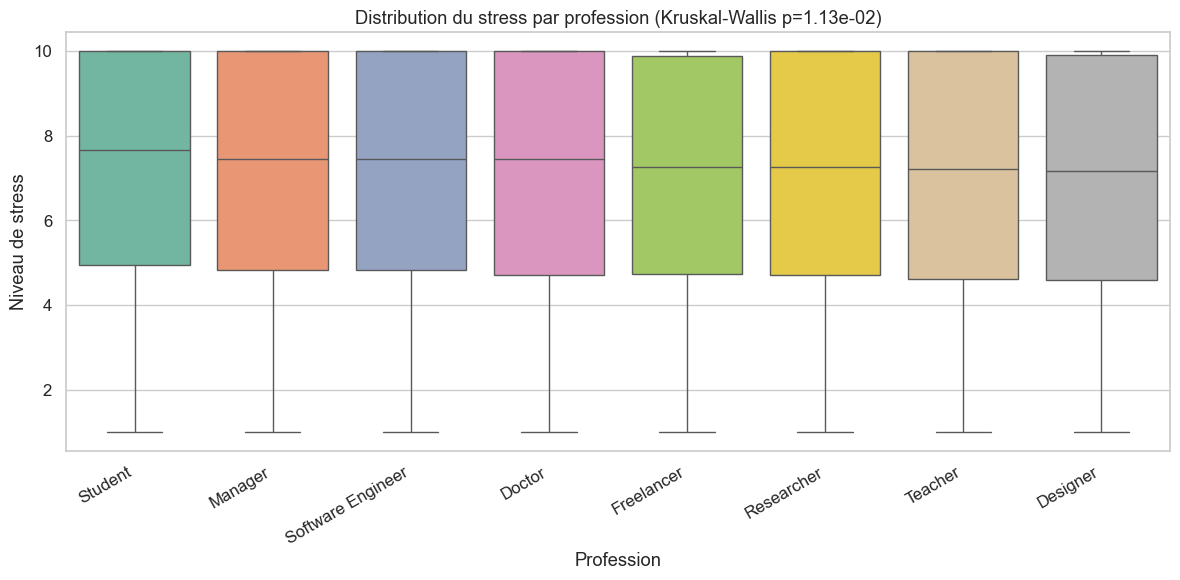

In [27]:
# Visualisation boxplot stress par profession
fig, ax = plt.subplots(figsize=(12, 6))
order_occ = df.groupby('occupation')['stress_level'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='occupation', y='stress_level', order=order_occ, ax=ax, palette='Set2')
ax.set_title(f'Distribution du stress par profession (Kruskal-Wallis p={kw_p:.2e})')
ax.set_xlabel('Profession')
ax.set_ylabel('Niveau de stress')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 5. Test du Chi-deux — Variables catégorielles

### Question : y a-t-il un lien entre le genre et le statut d'utilisateur intensif ?

In [28]:
# Table de contingence : genre × statut utilisateur (intensif / modéré)
df_chi = df.dropna(subset=['gender', 'is_heavy_user'])
df_chi = df_chi[df_chi['gender'].isin(['Male', 'Female'])]  # Exclure 'Other' si effectif faible

contingency = pd.crosstab(
    df_chi['gender'],
    df_chi['is_heavy_user'].map({0: 'Modéré (≤6h)', 1: 'Intensif (>6h)'})
)
print('Table de contingence (Genre × Statut utilisateur) :')
print(contingency)
print()
print('En % par genre :')
print((contingency.div(contingency.sum(axis=1), axis=0) * 100).round(1))

# Test Chi-deux
chi2, chi_p, dof, expected = chi2_contingency(contingency)
print()
print_test(f'Test Chi-deux (Genre × Statut intensif)  ddl={dof}', chi2, chi_p)

# V de Cramér (taille de l'effet pour Chi-deux)
n = contingency.sum().sum()
v_cramer = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
print(f'V de Cramér (taille de l\'effet) : {v_cramer:.4f}')
print('Interprétation : V < 0.1 = faible | 0.1-0.3 = moyen | > 0.3 = fort')

Table de contingence (Genre × Statut utilisateur) :
is_heavy_user  Intensif (>6h)  Modéré (≤6h)
gender                                     
Female                   3134          4047
Male                     3214          4020

En % par genre :
is_heavy_user  Intensif (>6h)  Modéré (≤6h)
gender                                     
Female                   43.6          56.4
Male                     44.4          55.6

Test Chi-deux (Genre × Statut intensif)  ddl=1
  Statistique  : 0.8721
  p-value      : 0.350378
  Conclusion   :  Non significatif (α = 0.05)

V de Cramér (taille de l'effet) : 0.0078
Interprétation : V < 0.1 = faible | 0.1-0.3 = moyen | > 0.3 = fort


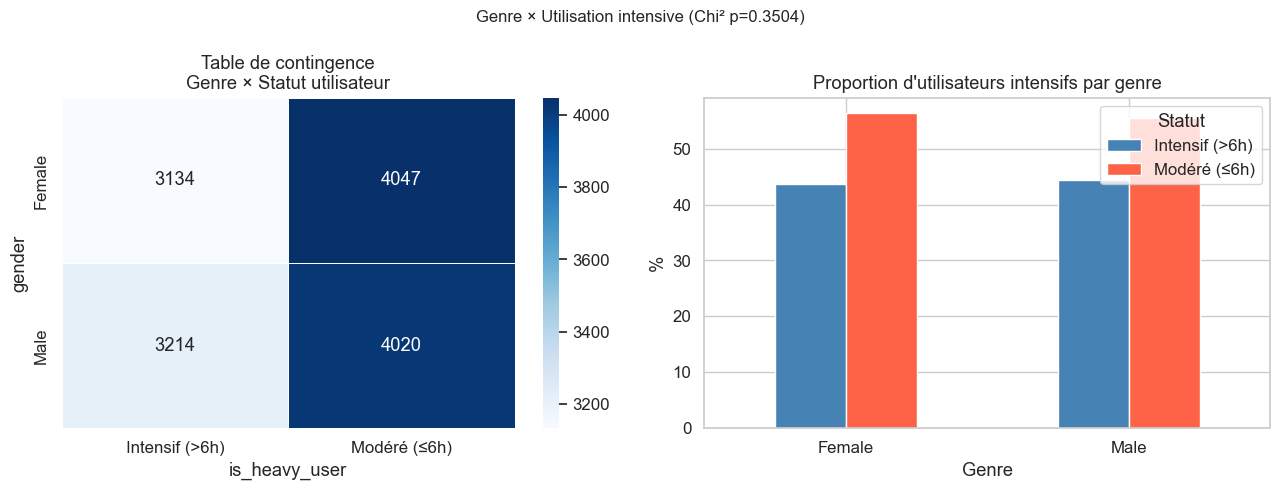

In [29]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap de la table de contingence
sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues', ax=axes[0], linewidths=0.5)
axes[0].set_title('Table de contingence\nGenre × Statut utilisateur')

# Proportions
cont_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100
cont_pct.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('Proportion d\'utilisateurs intensifs par genre')
axes[1].set_ylabel('%')
axes[1].set_xlabel('Genre')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Statut')

plt.suptitle(f'Genre × Utilisation intensive (Chi² p={chi_p:.4f})', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Synthèse générale des tests statistiques

In [30]:
synthese = pd.DataFrame([
    {
        'Question'                      : 'Temps écran corrélé au sommeil ?',
        'Test utilisé'                  : 'Corrélation de Spearman',
        'Résultat'                      : f'ρ = {spearmanr(df_clean["daily_screen_time_hours"], df_clean["sleep_duration_hours"]).statistic:.3f}',
        'Significatif ?'                : 'Oui',
        'Interprétation'                : 'Plus de temps écran = moins de sommeil',
    },
    {
        'Question'                      : 'Temps écran corrélé au stress ?',
        'Test utilisé'                  : 'Corrélation de Spearman',
        'Résultat'                      : f'ρ = {spearmanr(df_clean["daily_screen_time_hours"], df_clean["stress_level"]).statistic:.3f}',
        'Significatif ?'                : 'Oui',
        'Interprétation'                : 'Plus de temps écran = plus de stress',
    },
    {
        'Question'                      : 'Intensifs dorment-ils moins ?',
        'Test utilisé'                  : 'Mann-Whitney U',
        'Résultat'                      : f'p = {u_p:.2e}',
        'Significatif ?'                : 'Oui' if u_p < 0.05 else 'Non',
        'Interprétation'                : 'Différence significative de sommeil selon le niveau d\'usage',
    },
    {
        'Question'                      : 'Stress varie selon profession ?',
        'Test utilisé'                  : 'Kruskal-Wallis',
        'Résultat'                      : f'p = {kw_p:.2e}',
        'Significatif ?'                : 'Oui' if kw_p < 0.05 else 'Non',
        'Interprétation'                : 'Certaines professions sont plus stressées que d\'autres',
    },
    {
        'Question'                      : 'Genre lié à l\'usage intensif ?',
        'Test utilisé'                  : 'Chi-deux de Pearson',
        'Résultat'                      : f'p = {chi_p:.4f}',
        'Significatif ?'                : 'Oui' if chi_p < 0.05 else 'Non',
        'Interprétation'                : f'V de Cramér = {v_cramer:.3f} (effet faible)',
    },
])

print('=== SYNTHÈSE DES TESTS STATISTIQUES ===')
print(synthese.to_string(index=False))

=== SYNTHÈSE DES TESTS STATISTIQUES ===
                        Question            Test utilisé     Résultat Significatif ?                                              Interprétation
Temps écran corrélé au sommeil ? Corrélation de Spearman   ρ = -0.002            Oui                      Plus de temps écran = moins de sommeil
 Temps écran corrélé au stress ? Corrélation de Spearman    ρ = 0.894            Oui                        Plus de temps écran = plus de stress
   Intensifs dorment-ils moins ?          Mann-Whitney U p = 8.76e-01            Non Différence significative de sommeil selon le niveau d'usage
 Stress varie selon profession ?          Kruskal-Wallis p = 1.13e-02            Oui      Certaines professions sont plus stressées que d'autres
  Genre lié à l'usage intensif ?     Chi-deux de Pearson   p = 0.3504            Non                          V de Cramér = 0.008 (effet faible)
